In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data (2).csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [17]:
df['Дата'] = pd.to_datetime(df['Дата'])


Сгруппируйте данные по дате, посчитайте количество продаж

In [19]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [20]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

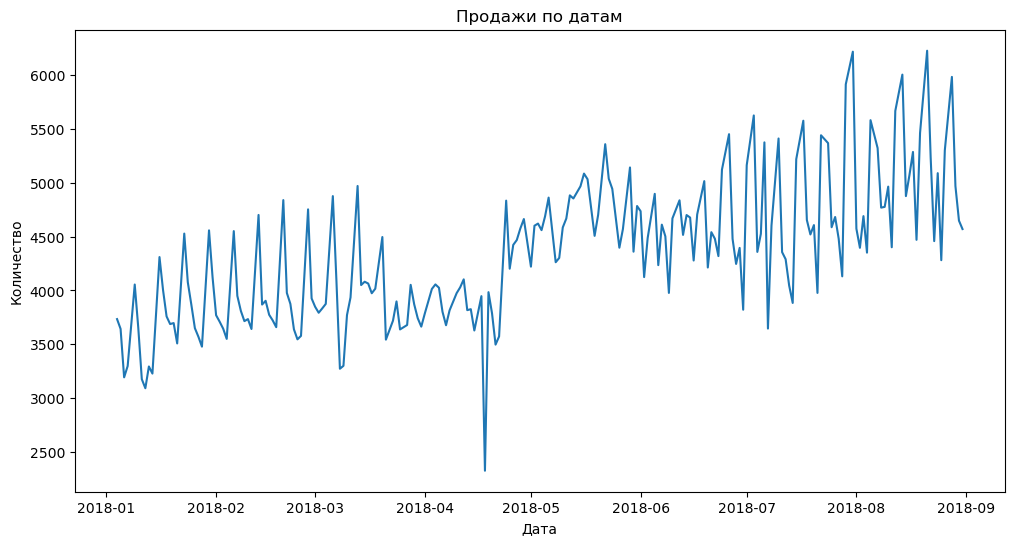

In [22]:
plt.figure(figsize=(12,6))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('Продажи по датам')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
#На графике представлена динамика количества продаж по датам за период с января по сентябрь 2018 года. 
#В начале периода продажи находятся на уровне примерно 3200–3800 единиц. Далее наблюдается постепенный рост объёма продаж.
#В данных присутствуют регулярные колебания, что может свидетельствовать о сезонности или различиях в продажах по дням недели. 
#Периодически возникают пики продаж, достигающие более 6000 единиц, особенно в летние месяцы.
#Также на графике заметен резкий спад продаж в середине апреля, который может быть связан с временными факторами, 
#такими как сбой поставок, праздничные дни или изменения спроса.
#В целом можно отметить положительный тренд — к концу периода средний уровень продаж увеличивается и держится в диапазоне 4500–6000 единиц.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [23]:
df.loc[df['Количество'].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [24]:
df['День_недели'] = df['Дата'].dt.dayofweek
df['Месяц'] = df['Дата'].dt.month

filtered = df[
    (df['День_недели'] == 2) & 
    (df['Месяц'].isin([6,7,8])) & 
    (df['Склад'] == 3)
]

filtered.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False).head(1)

Номенклатура
product_1    2267
Name: Количество, dtype: int64

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [93]:
weather = pd.read_csv(
    '35188.01.01.2018.31.12.2018.1.0.0.ru.utf8.00000000 (1).csv.gz',
    sep=';',
    compression='gzip',
    skiprows=6,
    usecols=[0, 2],
    names=['ДатаВремя','T'],
    engine='python'
)

weather.head()
weather = weather.iloc[1:]

In [94]:
weather = weather.iloc[1:].reset_index(drop=True)
weather.head()

,ДатаВремя,T
0,31.12.2018 20:00,744.3
1,31.12.2018 17:00,743.7
2,31.12.2018 14:00,742.9
3,31.12.2018 11:00,742.4
4,31.12.2018 08:00,741.9


In [95]:
weather['ДатаВремя'] = pd.to_datetime(
    weather['ДатаВремя'],
    format='%d.%m.%Y %H:%M'
)

In [96]:
weather['Дата'] = weather['ДатаВремя'].dt.date

In [99]:
weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

In [100]:
weather_daily = weather.groupby('Дата')['T'].mean().reset_index()

In [101]:
weather_daily.head()

,Дата,T
0,2018-01-01,747.9000
1,2018-01-02,745.3000
2,2018-01-03,742.7000
3,2018-01-04,744.6625
4,2018-01-05,745.3000


In [102]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.date

merged = pd.merge(grouped_df, weather_daily, on='Дата')

merged.head()

,Дата,Количество,T
0,2018-01-04,3734,744.6625
1,2018-01-05,3643,745.3000
2,2018-01-06,3193,744.2500
3,2018-01-07,3298,742.2375
4,2018-01-09,4055,734.1875


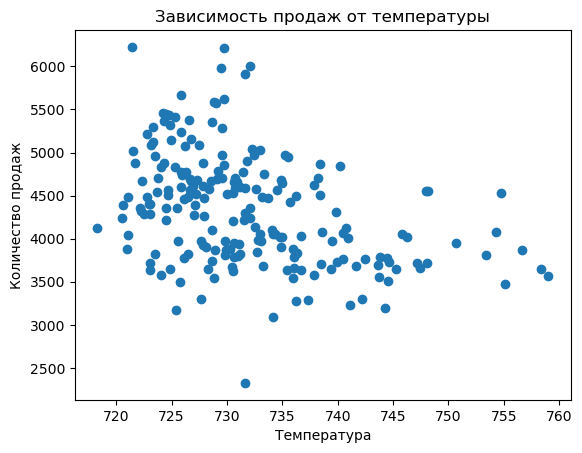

In [103]:
plt.scatter(merged['T'], merged['Количество'])
plt.xlabel('Температура')
plt.ylabel('Количество продаж')
plt.title('Зависимость продаж от температуры')
plt.show()

In [ ]:
#На графике показана зависимость количества продаж от температуры.
#Можно заметить, что при различных значениях температуры продажи изменяются.
#Однако явной линейной зависимости между температурой и количеством продаж не наблюдается.
#Большинство значений продаж находится в диапазоне примерно от 3500 до 5000 при температурах около 720–740.